In [1]:
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect("/Users/hp/OneDrive/Desktop/myc++/AI-ML/InvoiceSystem/data/inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",conn)

In [3]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [4]:
#for table in tables['name']:
#    print('table name', table)
#    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
#   display(df)

vendor_df = pd.read_sql_query("select * from vendor_invoice", conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [5]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


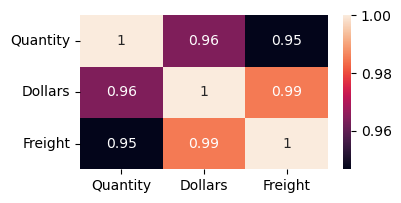

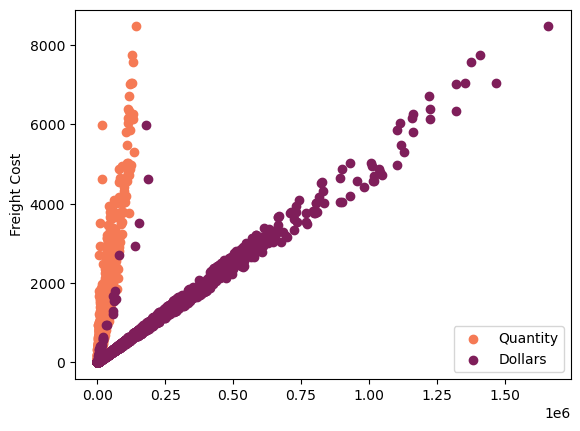

In [6]:
# Relationship between Quantity, Dollars and Freight
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity', 'Dollars', 'Freight']].corr(), annot = True)
plt.show()

plt.scatter(vendor_df['Quantity'], vendor_df['Freight'], color = '#f57a55')
plt.scatter(vendor_df['Dollars'], vendor_df['Freight'], color = '#7f1e5a')
plt.legend(['Quantity', 'Dollars'])
plt.ylabel('Freight Cost')
plt.show()

In [7]:
vendor_df['freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity'] 

In [8]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [9]:
vendor_df.loc[vendor_df['Quantity']<low_quantity, 'freight_per_unit']

0       0.578333
1       0.571333
2       0.922000
5       0.100000
7       0.881667
          ...   
5523    0.102778
5526    0.088308
5527    0.048611
5528    0.032000
5537    0.053333
Name: freight_per_unit, Length: 1384, dtype: float64

In [10]:
vendor_df.loc[vendor_df['Quantity']>high_quantity, 'freight_per_unit']

3       0.290614
14      0.183063
18      0.359743
22      0.160885
32      0.301962
          ...   
5529    0.036190
5530    0.029653
5532    0.071002
5540    0.094735
5541    0.033117
Name: freight_per_unit, Length: 1386, dtype: float64

In [29]:
x = vendor_df[['Dollars']]
y = vendor_df['Freight']

In [30]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(
    x,y,test_size = 0.2, random_state = 42
)

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [32]:
model1 = LinearRegression()
model1.fit(xtrain,ytrain)

model2 = DecisionTreeRegressor(max_depth = 4, random_state = 42)
model2.fit(xtrain,ytrain)

model3 = RandomForestRegressor(random_state = 42)
model3.fit(xtrain,ytrain)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds) * 100

    print(f"\n{model_name} Performance:")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.2f}%")

In [33]:
evaluate_model(model1, xtest, ytest, 'LinearRegression')
evaluate_model(model2, xtest, ytest, 'Decision Tree Regressor')
evaluate_model(model3, xtest, ytest, 'Random Forest Regressor')


LinearRegression Performance:
MAE  : 24.11
RMSE : 15555.32
R²   : 96.99%

Decision Tree Regressor Performance:
MAE  : 38.12
RMSE : 19112.51
R²   : 96.30%

Random Forest Regressor Performance:
MAE  : 28.27
RMSE : 20224.79
R²   : 96.08%


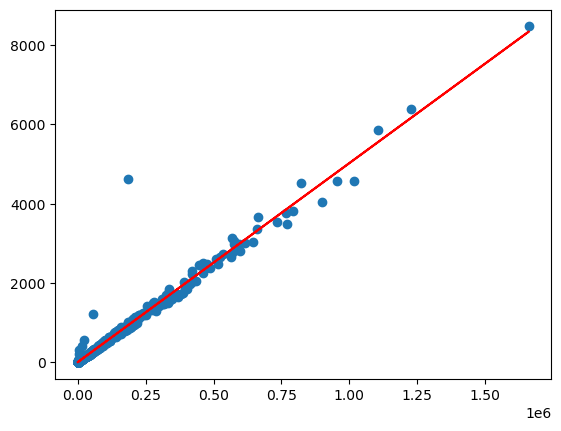

In [34]:
plt.scatter(xtest,ytest)
plt.plot(xtest,model1.predict(xtest), color='red')

In [37]:
input_data = {
    "Dollars": [20000,8000]
}
df1 = pd.DataFrame(input_data)

In [38]:
model1.predict(df1)

array([105.31143791,  45.12938751])